In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
df_original = pd.read_csv('Mall_Customers.csv')

In [3]:
df = df_original.copy()

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
X  = df.iloc[:,[3,4]]

In [8]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

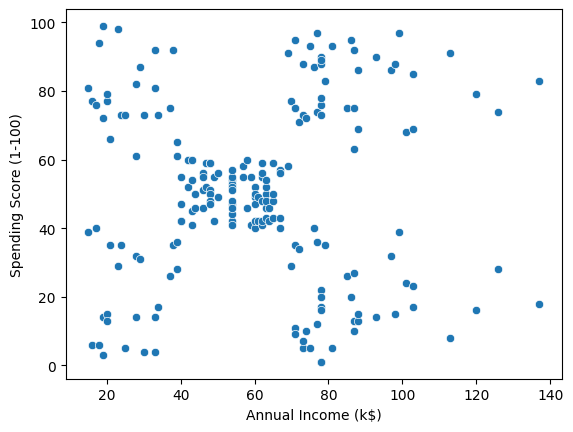

In [9]:
sns.scatterplot(x = df['Annual Income (k$)'],y = df['Spending Score (1-100)'])

In [10]:
wcss = []
k_range = range(1,11)
for i in k_range:
  kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

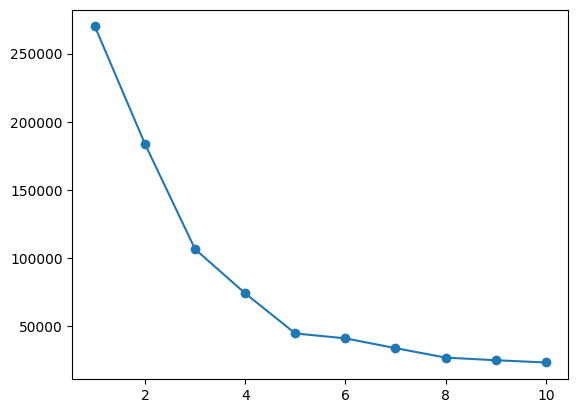

In [11]:
plt.plot(k_range,wcss,marker = 'o')

In [12]:
kmeans = KMeans(n_clusters=5,init = 'k-means++',random_state=42)
y_pred = kmeans.fit_predict(X)


In [13]:
y_pred

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

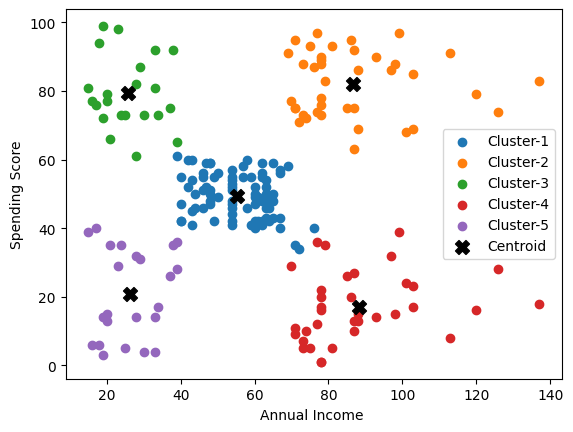

In [14]:
plt.scatter(X.iloc[y_pred == 0,0],X.iloc[y_pred == 0,1],label = 'Cluster-1')
plt.scatter(X.iloc[y_pred == 1,0],X.iloc[y_pred == 1,1],label = 'Cluster-2')
plt.scatter(X.iloc[y_pred == 2,0],X.iloc[y_pred == 2,1],label = 'Cluster-3')
plt.scatter(X.iloc[y_pred == 3,0],X.iloc[y_pred == 3,1],label = 'Cluster-4')
plt.scatter(X.iloc[y_pred == 4,0],X.iloc[y_pred == 4,1],label = 'Cluster-5')

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s = 100,
    c = 'black',
    marker = 'X',
    label = 'Centroid'
)
plt.xlabel('Annual Income ')
plt.ylabel("Spending Score")
plt.legend()
plt.show()